In [18]:
# manipulacja danymi
import numpy as np
import pandas as pd

# wizualizacja danych
import matplotlib.pyplot as plt
import seaborn as sns

# statystyczna analiza danych
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [19]:
np.random.seed(42)
sample_100 = np.random.normal(loc=3, scale=1, size=100)
sample_10k = np.random.normal(loc=3, scale=1, size=10000)
df_100 = pd.DataFrame(sample_100, columns=["Value"])
df_10k = pd.DataFrame(sample_10k, columns=["Value"])

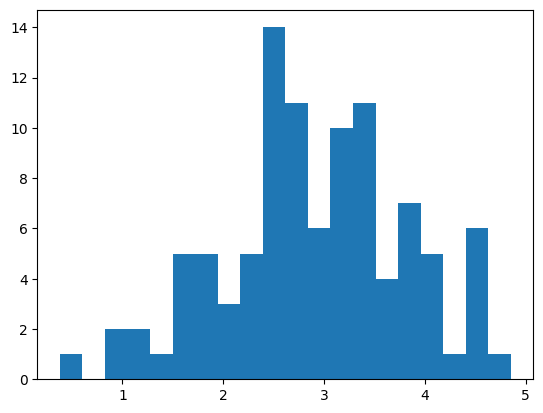

In [20]:
plt.hist(sample_100, bins=20)
plt.show()

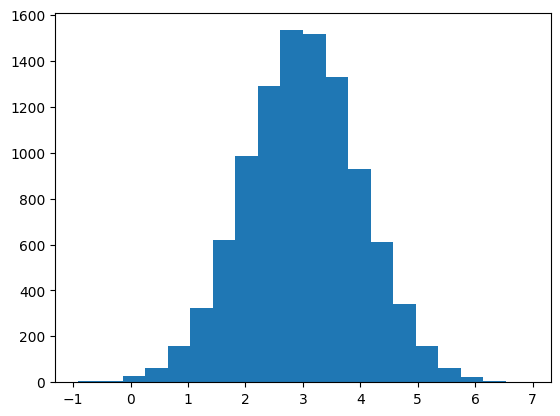

In [21]:
plt.hist(sample_10k, bins=20)
plt.show()

Wnioski: Wraz ze wzrostem liczby próbek histogram coraz lepiej odwzorowuje rozkład normalny.

In [22]:
def statistics(data):
    return pd.Series({
        "Średnia": data.mean(),
        "Mediana": data.median(),
        "Odchylenie standardowe": data.std(),
        "Wariancja": data.var(),
        "Minimum": data.min(),
        "Maksimum": data.max(),
        "Moda": data.mode()[0]
    })

stats_100 = statistics(df_100["Value"])
stats_10k = statistics(df_10k["Value"])

comparison = pd.DataFrame({
    "100 próbek": stats_100,
    "10000 próbek": stats_10k
})

comparison

,100 próbek,10000 próbek
Średnia,2.896153,2.998821
Mediana,2.873044,2.998835
Odchylenie standardowe,0.908168,1.003741
Wariancja,0.824770,1.007497
Minimum,0.380255,-0.922400
Maksimum,4.852278,6.926238
Moda,0.380255,-0.922400


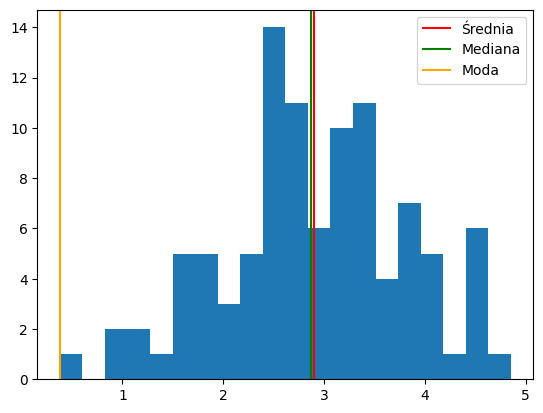

In [23]:
plt.hist(df_100, bins=20)
plt.axvline(x=stats_100["Średnia"], color='red', label='Średnia')
plt.axvline(x=stats_100["Mediana"], color='green', label='Mediana')
plt.axvline(x=stats_100["Moda"], color='orange', label='Moda')
plt.legend(loc='upper right')
plt.show()

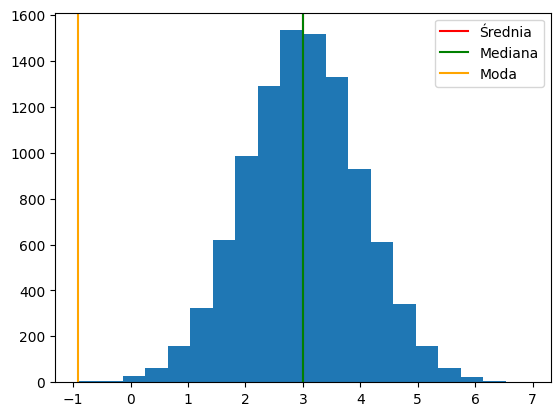

In [24]:
plt.hist(df_10k, bins=20)
plt.axvline(x=stats_10k["Średnia"], color='red', label='Średnia')
plt.axvline(x=stats_10k["Mediana"], color='green', label='Mediana')
plt.axvline(x=stats_10k["Moda"], color='orange', label='Moda')
plt.legend(loc='upper right')
plt.show()

Wnioski: Dla dużej liczby próbek średnia i mediana są bardzo zbliżone do wartości oczekiwanej (3). Dla mniejszej próbki różnice są większe.
Moda w tym wypadku przyjmuje wartość najmniejszej próbki(Tak przyjąłem żeby można było to wyświetlić) ponieważ przy takim rozkłądzie każda wartość pojawi się raz i wszystkie wartości wystąpią równo 1 raz. Tak naprawdę w wyniku metody powstanie seria wszystkich punktów tego rozkładu.

In [25]:
q0 = np.quantile(sample_100, 0.0)
q1 = np.quantile(sample_100, 0.25)
q3 = np.quantile(sample_100, 0.75)
q4 = np.quantile(sample_100, 1.0)

print(f'Q0: {q0}')
print(f'Q1: {q1}')
print(f'Q2: {stats_100["Mediana"]}')
print(f'Q3: {q3}')
print(f'Q4: {q4}')

Q0: 0.38025489591025563
Q1: 2.399094329503547
Q2: 2.8730437082202873
Q3: 3.4059520520120623
Q4: 4.852278184508938


In [26]:
range_100 = max(sample_100) - min(sample_100)
print(range_100)
iqr = q3 - q1
print(iqr)
variance = np.var(sample_100, ddof=1)
print(variance)
standard_deviation = np.std(sample_100, ddof=1)
print(standard_deviation)

4.472023288598683
1.0068577225085154
0.82476989363016
0.9081684280078007


In [27]:
q0 = np.quantile(sample_10k, 0.0)
q1 = np.quantile(sample_10k, 0.25)
q3 = np.quantile(sample_10k, 0.75)
q4 = np.quantile(sample_10k, 1.0)

print(f'Q0: {q0}')
print(f'Q1: {q1}')
print(f'Q2: {stats_10k["Mediana"]}')
print(f'Q3: {q3}')
print(f'Q4: {q4}')

Q0: -0.9224002516183423
Q1: 2.3264345054022297
Q2: 2.998834844229987
Q3: 3.6720318078709733
Q4: 6.926237706436327


In [28]:
range_10k = max(sample_10k) - min(sample_10k)
print(range_10k)
iqr = q3 - q1
print(iqr)
variance = np.var(sample_10k, ddof=1)
print(variance)
standard_deviation = np.std(sample_10k, ddof=1)
print(standard_deviation)

7.848637958054669
1.3455973024687435
1.0074968272097058
1.0037414145135717


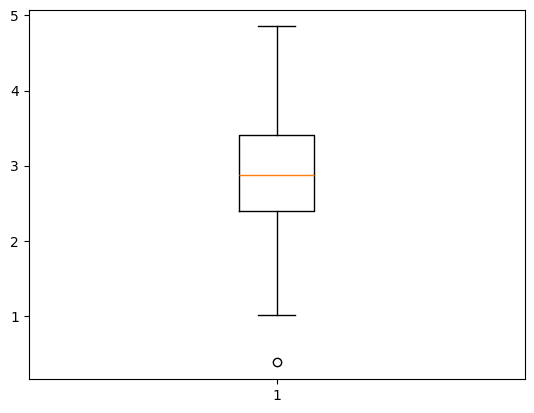

In [29]:
plt.boxplot(sample_100)
plt.show()

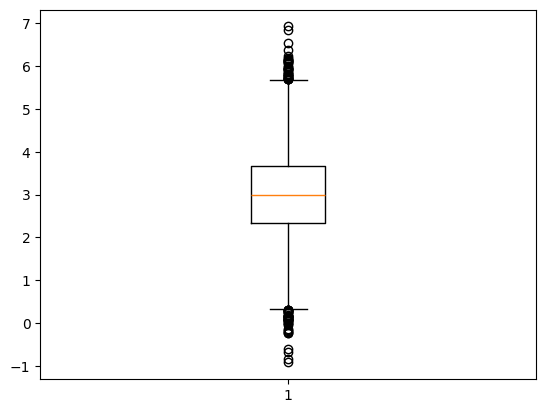

In [30]:
plt.boxplot(sample_10k)
plt.show()

W większej próbie pojawiło się więcej wartości oznaczonych jako odstające. Nie świadczy to o błędach danych, lecz wynika z większej liczby obserwacji oraz właściwości rozkładu normalnego.

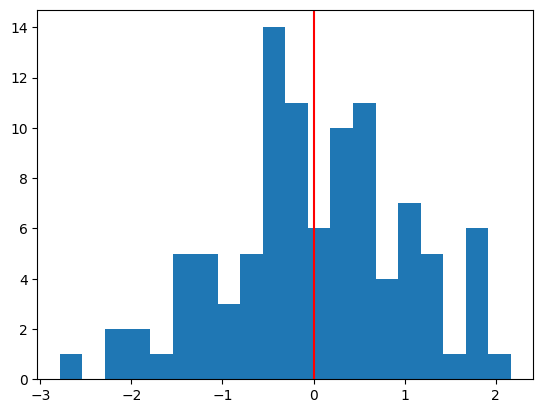

Średnia: 7.802092305553287e-16
Odchylenie standardowe sample 100: 1.005037815259212


In [31]:
scaler_standardized = StandardScaler()
standardized_values = scaler_standardized.fit_transform(
    sample_100.reshape(-1, 1)
)

plt.hist(standardized_values, bins=20)
plt.axvline(
    x=standardized_values.mean(),
    color='red',
    label='Średnia'
)
plt.show()

print(f'Średnia: {standardized_values.mean()}')
print(
    f'Odchylenie standardowe sample 100: '
    f'{np.std(standardized_values, ddof=1)}'
)

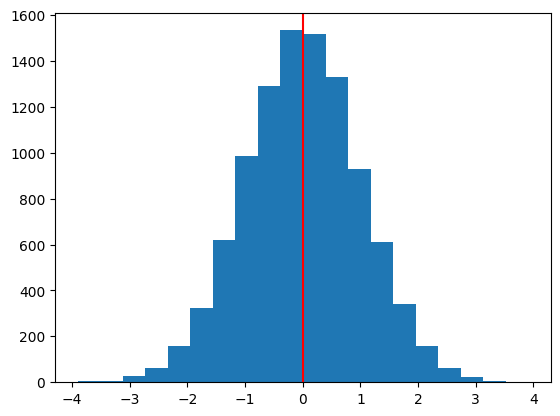

Średnia: -4.263256414560601e-17
Odchylenie standardowe sample 10k: 1.0000500037503124


In [32]:
scaler_standardized = StandardScaler()
standardized_values = scaler_standardized.fit_transform(
    sample_10k.reshape(-1, 1)
)

plt.hist(standardized_values, bins=20)
plt.axvline(
    x=standardized_values.mean(),
    color='red',
    label='Średnia'
)
plt.show()

print(f'Średnia: {standardized_values.mean()}')
print(
    f'Odchylenie standardowe sample 10k: '
    f'{np.std(standardized_values, ddof=1)}'
)

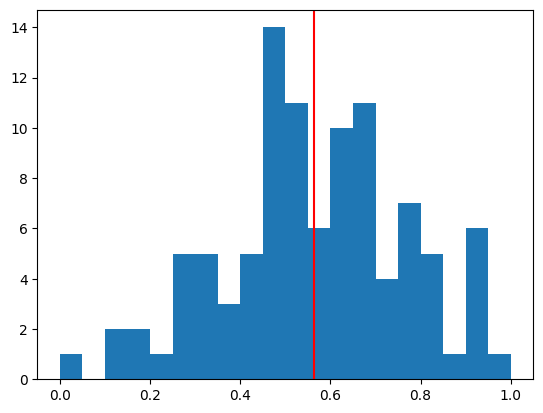

Średnia sample 100: 0.5625861996537169
Odchylenie standardowe sample 100: 0.2030777501367568


In [33]:
scaler_MinMax = MinMaxScaler()
normalized_values = scaler_MinMax.fit_transform(
    sample_100.reshape(-1, 1)
)

plt.hist(normalized_values, bins=20)
plt.axvline(
    x=normalized_values.mean(),
    color='red',
    label='Średnia'
)
plt.show()

print(f'Średnia sample 100: {normalized_values.mean()}')
print(
    f'Odchylenie standardowe sample 100: '
    f'{np.std(normalized_values, ddof=1)}'
)

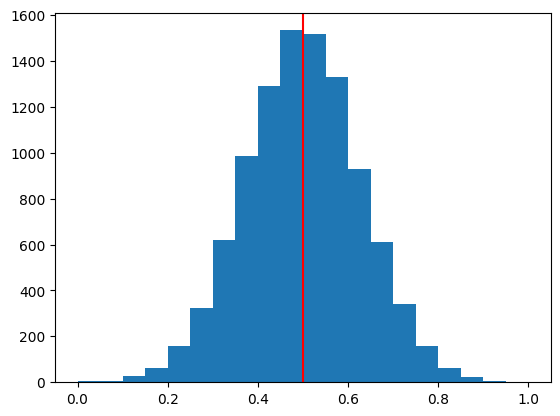

Średnia sample 10k: 0.49960532488461684
Odchylenie standardowe sample 10k: 0.1278873378894336


In [34]:
scaler_MinMax = MinMaxScaler()
normalized_values = scaler_MinMax.fit_transform(
    sample_10k.reshape(-1, 1)
)

plt.hist(normalized_values, bins=20)
plt.axvline(
    x=normalized_values.mean(),
    color='red',
    label='Średnia'
)
plt.show()

print(f'Średnia sample 10k: {normalized_values.mean()}')
print(
    f'Odchylenie standardowe sample 10k: '
    f'{np.std(normalized_values, ddof=1)}'
)

Wnioski: Wariancja i odchylenie standardowe dla większej próby są bliższe wartościom zadanym podczas generowania danych.